#  Loan Default Prediction — Machine Learning Project

The objective of this project is to build a machine learning model to predict whether a loan will be paid back or not.  
The dataset contains customer financial details and demographic information. The target variable is **`loan_paid_back`** (1 = loan repaid, 0 = loan default).

**Dataset Source**:
This dataset is publicly available on Kaggle as part of the "Playground Series - Season 5 Episode 11" competition:
🔗 https://www.kaggle.com/competitions/playground-series-s5e11/data

**In this project,**

 Phase 1 — Understanding the Dataset  
 Phase 2 — Exploratory Data Analysis (EDA)  
 Phase 3 — Data Cleaning & Preprocessing  
 Phase 4 — Model Building and evaluated several classification models:
  - Logistic Regression (baseline)
  - Random Forest
  - XGBoost
  - CatBoost
    
 Phase 5 — Model Evaluation & Optimization  


## 🔍 Phase 1 — Understanding the Dataset

In this phase, the goal is to load the dataset and become familiar with its structure.  
Key objectives of Phase 1:
- Load dataset from file
- View sample records
- Check dataset size (rows & columns)
- List column names
- Check data types of each column
- Get dataset summary using `info()`
- Understand the target column `loan_paid_back`

This step is important before performing EDA or building ML models.

In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',None)

In [4]:
file_path = r"data/playground-series-s5e11/train.csv"
df = pd.read_csv(file_path)
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [5]:
file_path_test = r"data/playground-series-s5e11/test.csv"
df_test = pd.read_csv(file_path_test)
df_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [6]:
rows,cols= df.shape
print(f"Rows:{rows},Columns:{cols}")

Rows:593994,Columns:13


In [7]:
df.columns.tolist()


['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade',
 'loan_paid_back']

In [8]:
df_test.columns.tolist()

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [9]:
df.dtypes

id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object

In [10]:
df_test.dtypes

id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
dtype: object

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [12]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    254569 non-null  int64  
 1   annual_income         254569 non-null  float64
 2   debt_to_income_ratio  254569 non-null  float64
 3   credit_score          254569 non-null  int64  
 4   loan_amount           254569 non-null  float64
 5   interest_rate         254569 non-null  float64
 6   gender                254569 non-null  object 
 7   marital_status        254569 non-null  object 
 8   education_level       254569 non-null  object 
 9   employment_status     254569 non-null  object 
 10  loan_purpose          254569 non-null  object 
 11  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 23.3+ MB


In [13]:
df.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [14]:
print(df['loan_paid_back'].unique())
print(df['loan_paid_back'].value_counts())
print(df['loan_paid_back'].value_counts(normalize=True) * 100)


[1. 0.]
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64





**Observation**

The dataset is imbalanced.
The target column loan_paid_back contains approximately 79.88% class 1 (loan repaid) and 20.11% class 0 (loan default).






We successfully:
- Loaded the dataset into Python
- Viewed sample records
- Checked dataset size (rows & columns)
- Listed all column names
- Examined train data types of each column-(int- 2, Float-5,object-6)
- Examined test data types of each column-(int- 1, Float-5,object-6)
- Viewed dataset summary using `info()`
- Analyzed distribution of the target variable (`loan_paid_back`)- which look imbalanced data set.

# Phase 2: Exploratory Data Analysis (EDA)  
In the next phase we will:
- Check missing values
- View summary statistics
- Analyze numerical feature distributions
- Analyze categorical feature frequencies
- Understand relationships between features and the target variable
- Visualize correlation between numerical features




In [15]:
# 1. Check number of missing values

df.isnull().sum()


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [16]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [17]:
df_test.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64

In [18]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


### Visualizing Numerical Data Distributions of train data
Histograms help understand the spread of numerical features and detect:
- Skewness
- Outliers
- Non-normal distributions


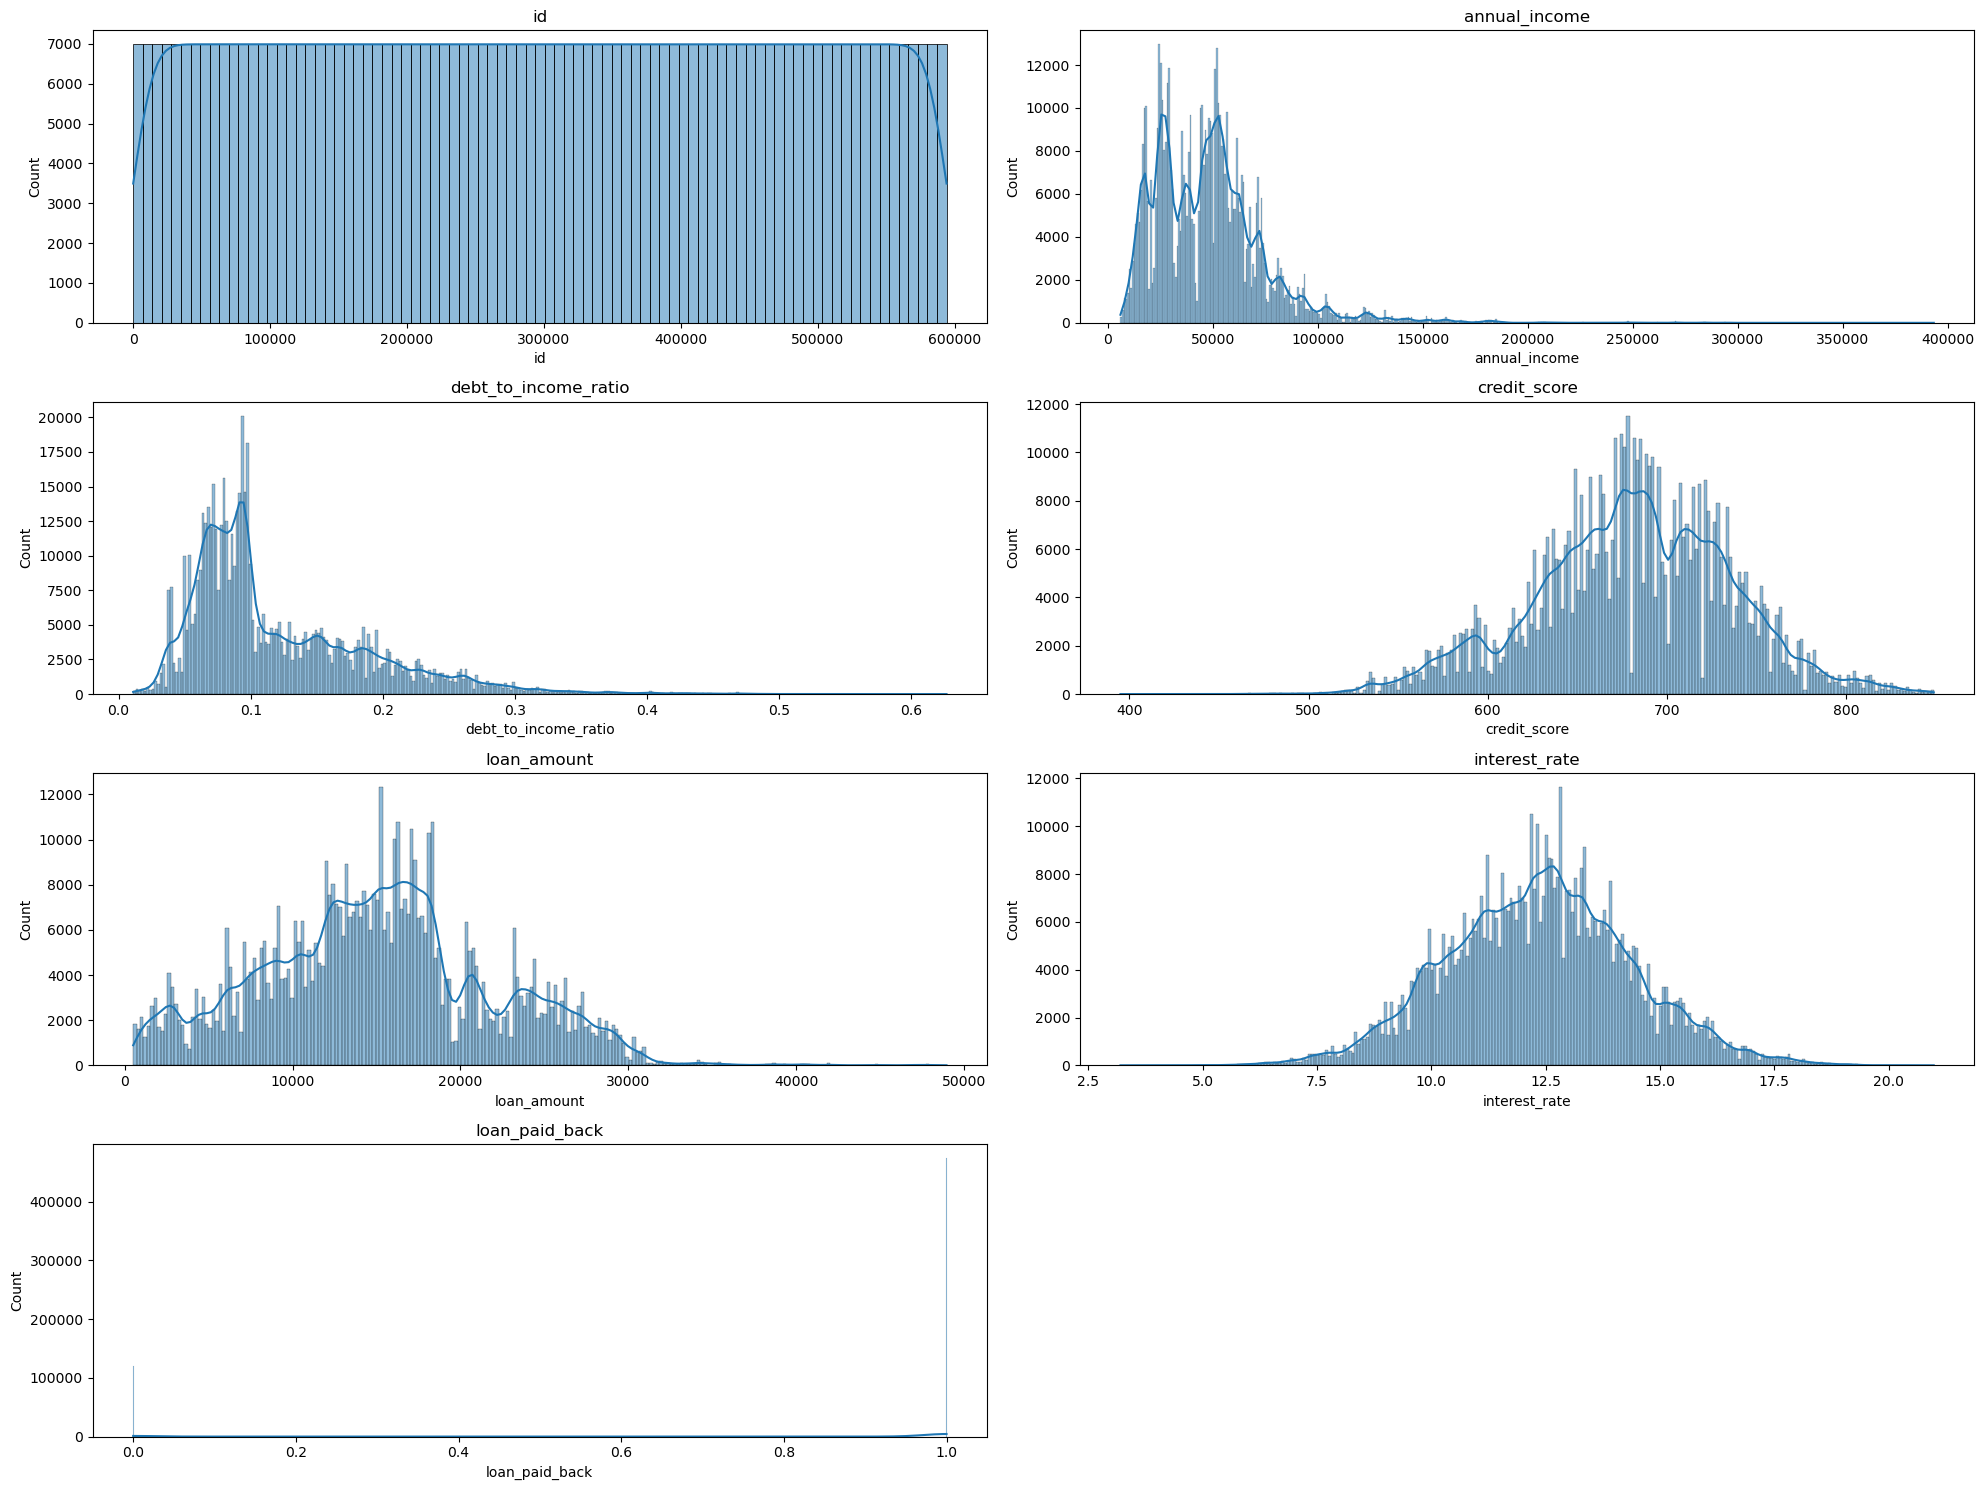

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 15))
for i, cols in enumerate(num_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[cols], kde=True)
    plt.title(cols)
plt.tight_layout()
plt.show()




**observation**
id has not relation with loan_paid_back



### Frequency Distribution of Categorical Features
Bar plots help analyze:
- Most common categories
- Rare categories
- Possible feature–target relationships


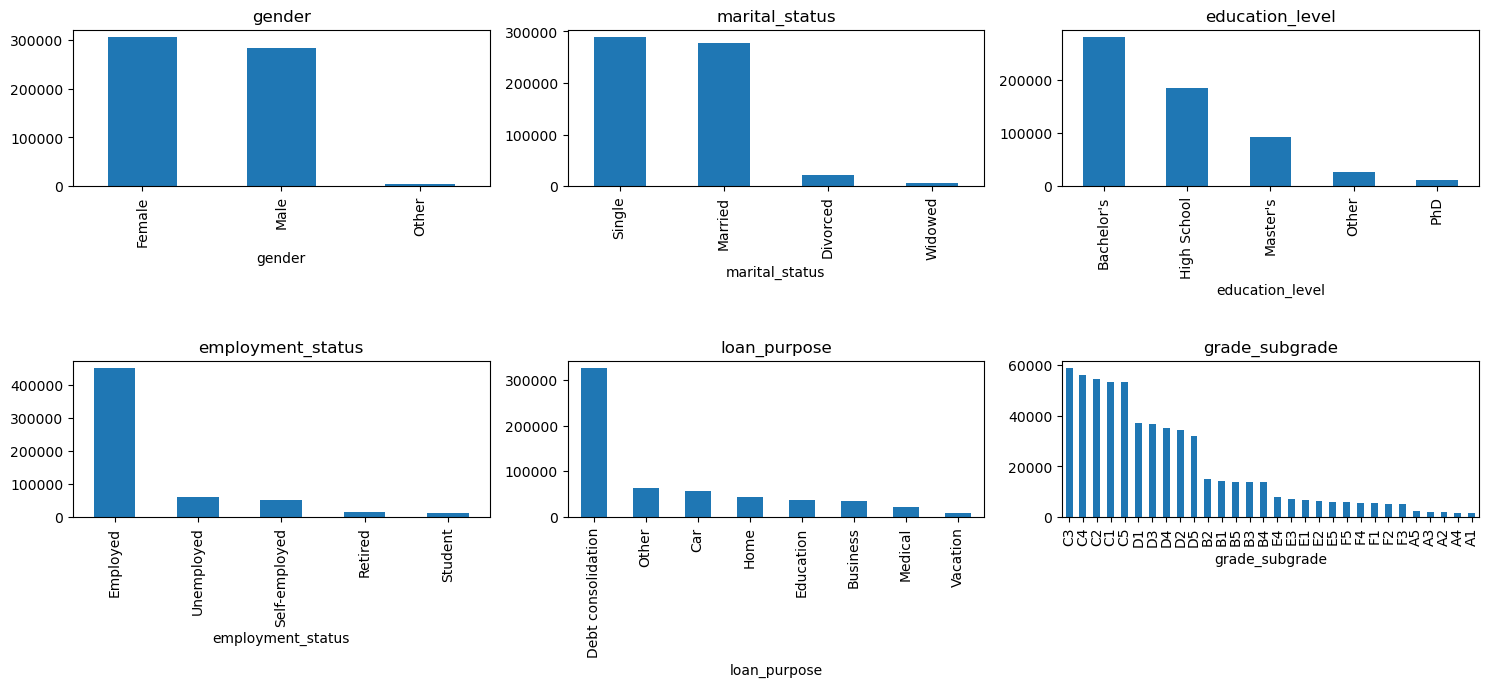

In [22]:
cat_cols = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
plt.tight_layout()
plt.show()


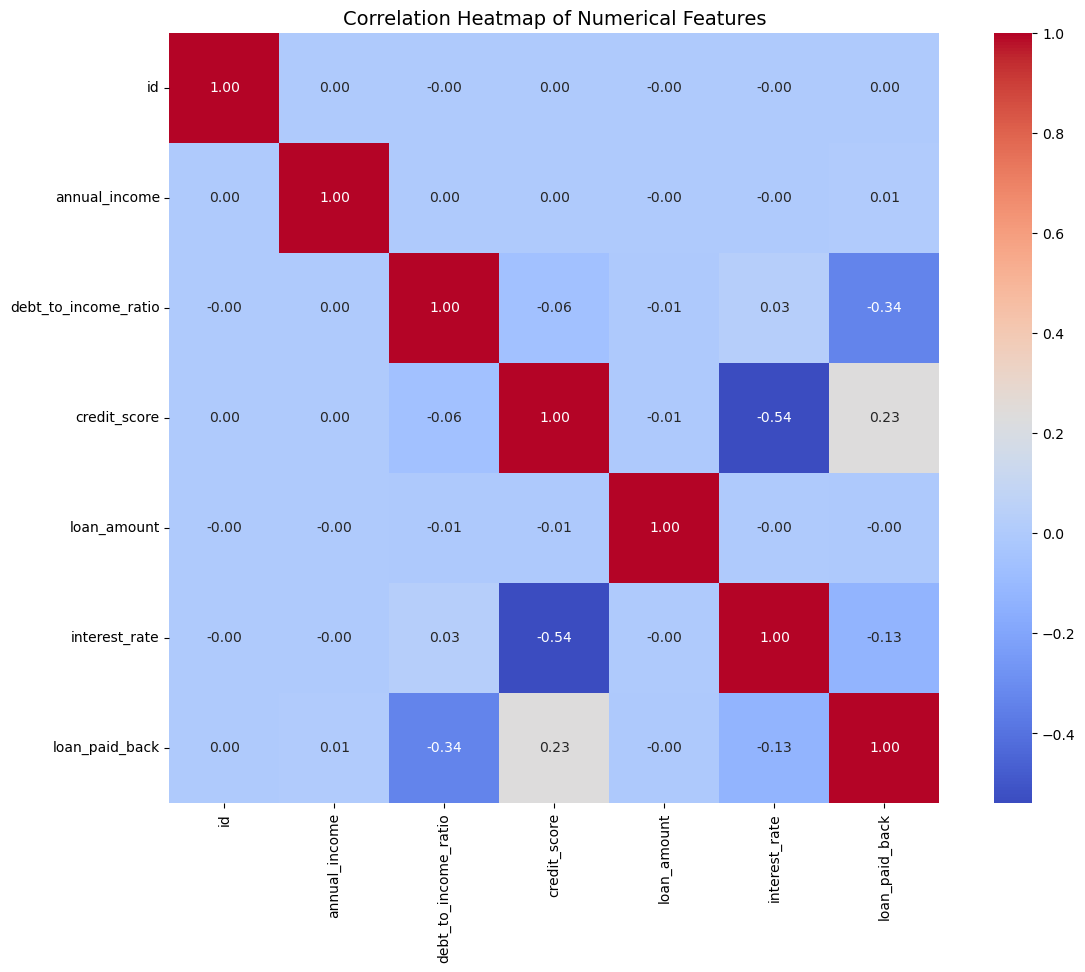

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)   # numeric_only avoids errors with categorical columns
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()


### 🧠 Phase 2 Observations — Exploratory Data Analysis (EDA)

Based on the visualizations and statistical analysis:

#### 🔹 Numerical Features
- Several numerical variables show **right-skewed distributions**, indicating the presence of extreme values or long tails.
- A few variables contain **outliers**, which could influence model performance if not handled properly.
- Some numerical features show **moderate correlation** with the target variable `loan_paid_back`, indicating predictive value.

#### 🔹 Categorical Features
- Certain categories dominate in variables like marital status, employment type, and education level.
- Category-wise bar plots show **clear differences between customers who repaid and those who defaulted**, suggesting these features could be valuable for the model.

#### 🔹 Target Variable
- The dataset is **imbalanced** — most loans are repaid (`loan_paid_back = 1`) compared to defaulted (`loan_paid_back = 0`).  
  This means **accuracy alone is not a reliable metric**, and recall/F1-score for the default class will be important.

#### 🔹 Correlation Insights
- A few features show **positive or negative correlation** with `loan_paid_back`, while many features are weakly correlated — indicating that **non-linear ML models may perform better than linear models**.

---

### 📌 Conclusion of Phase 2
EDA confirms that:
- Preprocessing is required (handling missing values, encoding categorical variables, scaling ).
- Class imbalance must be considered while evaluating models.
- Several features are relevant and should improve model performance after preprocessing.

Next step → **Phase 3 — Data Cleaning & Preprocessing**


## 🛠 Phase 3 — Data Cleaning & Pre-processing

Before training ML models, the dataset must be converted into a clean and machine-readable form.

In this phase, we will perform:
- Missing value handling
- Outlier detection and treatment
- Encoding categorical features
- Scaling/normalizing numerical features
- Train/Test split
- Imbalance handling (because our target is imbalanced)

A properly pre-processed dataset ensures higher model accuracy and generalization.



In [24]:
df.isnull().sum()


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols[1:5]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"{col},lower:{lower},higher:{upper},IQR:{IQR}")

annual_income,lower:-21635.979999999996,higher:110551.7,IQR:33046.92
debt_to_income_ratio,lower:-0.054000000000000006,higher:0.28200000000000003,IQR:0.084
credit_score,lower:536.5,higher:828.5,IQR:73.0
loan_amount,lower:-2588.8200000000015,higher:31727.020000000004,IQR:8578.960000000001


In [26]:
print("Check target distribution just before train_test_split:")
print(df['loan_paid_back'].value_counts())
print(df['loan_paid_back'].value_counts(normalize=True) * 100)
print("Unique values in target:", df['loan_paid_back'].unique())


Check target distribution just before train_test_split:
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64
Unique values in target: [1. 0.]


In [27]:
for col in num_cols[1:5]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [28]:
print("Check target distribution just before train_test_split:")
print(df['loan_paid_back'].value_counts())
print(df['loan_paid_back'].value_counts(normalize=True) * 100)
print("Unique values in target:", df['loan_paid_back'].unique())


Check target distribution just before train_test_split:
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64
Unique values in target: [1. 0.]


In [29]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True,dtype=int)
df.head()


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,gender_Male,gender_Other,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,0,29367.99,0.084,736.0,2528.42,13.67,1.0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,22108.02,0.166,636.0,4593.10,12.92,0.0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,49566.20,0.097,694.0,17005.15,9.76,1.0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,46858.25,0.065,536.5,4682.48,16.10,1.0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,4,25496.70,0.053,665.0,12184.43,10.21,1.0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [30]:
df.shape

(593994, 56)

In [31]:
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True,dtype=int)
df_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender_Male,gender_Other,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,593994,28781.05,0.049,626,11461.42,14.73,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,593995,46626.39,0.093,732,15492.25,12.85,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,593996,54954.89,0.367,611,3796.41,13.29,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,593997,25644.63,0.110,671,6574.30,9.57,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,593998,25169.64,0.081,688,17696.89,12.80,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
print("Check target distribution just before train_test_split:")
print(df['loan_paid_back'].value_counts())
print(df['loan_paid_back'].value_counts(normalize=True) * 100)
print("Unique values in target:", df['loan_paid_back'].unique())


Check target distribution just before train_test_split:
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64
Unique values in target: [1. 0.]


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_paid_back', axis=1)
X = X.drop('id', axis=1) 
y = df['loan_paid_back']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20,random_state=42, stratify=y)


In [34]:
print(y_train.value_counts())
print("Unique classes in y_train:", y_train.unique())


loan_paid_back
1.0    379595
0.0     95600
Name: count, dtype: int64
Unique classes in y_train: [1. 0.]


In [35]:
X_test = df_test.drop('id',axis=1)
id=df_test['id']

In [36]:
X_test.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender_Male,gender_Other,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,28781.05,0.049,626,11461.42,14.73,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,46626.39,0.093,732,15492.25,12.85,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,54954.89,0.367,611,3796.41,13.29,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,25644.63,0.110,671,6574.30,9.57,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,25169.64,0.081,688,17696.89,12.80,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_valid = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)


In [38]:
X_test

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender_Male,gender_Other,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,-0.790277,-1.103250,-0.998516,-0.516164,1.181878,-0.956256,-0.07956,-0.934890,1.027043,-0.106466,1.49488,-0.431347,-0.217084,-0.137290,-0.16892,-0.310679,-0.143325,-0.342964,-0.328710,-1.098251,-0.256895,-0.283356,-0.199916,2.885601,-0.120516,-0.058215,-0.059351,-0.052998,-0.064669,-0.157412,-0.161910,-0.15486,-0.154902,-0.155045,-0.314172,-0.318106,-0.331286,-0.322507,-0.313719,-0.258154,-0.247718,-0.256783,-0.249926,4.182974,-0.108162,-0.10458,-0.110018,-0.11674,-0.101557,-0.097172,-0.09384,-0.093291,-0.096674,-0.100526
1,-0.031380,-0.410830,0.926595,0.071385,0.245489,-0.956256,-0.07956,1.069645,-0.973669,-0.106466,-0.66895,2.318320,-0.217084,-0.137290,-0.16892,-0.310679,-0.143325,-0.342964,-0.328710,-1.098251,-0.256895,-0.283356,-0.199916,2.885601,-0.120516,-0.058215,-0.059351,-0.052998,-0.064669,-0.157412,-0.161910,-0.15486,-0.154902,-0.155045,3.182970,-0.318106,-0.331286,-0.322507,-0.313719,-0.258154,-0.247718,-0.256783,-0.249926,-0.239064,-0.108162,-0.10458,-0.110018,-0.11674,-0.101557,-0.097172,-0.09384,-0.093291,-0.096674,-0.100526
2,0.322800,3.901058,-1.270937,-1.633444,0.464644,1.045745,-0.07956,-0.934890,1.027043,-0.106466,-0.66895,-0.431347,-0.217084,-0.137290,-0.16892,-0.310679,-0.143325,-0.342964,-0.328710,0.910538,-0.256895,-0.283356,-0.199916,-0.346548,-0.120516,-0.058215,-0.059351,-0.052998,-0.064669,-0.157412,-0.161910,-0.15486,-0.154902,-0.155045,-0.314172,-0.318106,-0.331286,-0.322507,-0.313719,3.873657,-0.247718,-0.256783,-0.249926,-0.239064,-0.108162,-0.10458,-0.110018,-0.11674,-0.101557,-0.097172,-0.09384,-0.093291,-0.096674,-0.100526
3,-0.923657,-0.143305,-0.181252,-1.228529,-1.388211,-0.956256,-0.07956,-0.934890,1.027043,-0.106466,-0.66895,-0.431347,-0.217084,-0.137290,-0.16892,-0.310679,-0.143325,-0.342964,-0.328710,0.910538,-0.256895,-0.283356,-0.199916,-0.346548,-0.120516,-0.058215,-0.059351,-0.052998,-0.064669,-0.157412,-0.161910,-0.15486,-0.154902,-0.155045,-0.314172,-0.318106,3.018544,-0.322507,-0.313719,-0.258154,-0.247718,-0.256783,-0.249926,-0.239064,-0.108162,-0.10458,-0.110018,-0.11674,-0.101557,-0.097172,-0.09384,-0.093291,-0.096674,-0.100526
4,-0.943857,-0.599672,0.127492,0.392742,0.220585,-0.956256,-0.07956,1.069645,-0.973669,-0.106466,-0.66895,-0.431347,-0.217084,7.283867,-0.16892,-0.310679,-0.143325,-0.342964,-0.328710,-1.098251,-0.256895,-0.283356,-0.199916,-0.346548,-0.120516,-0.058215,-0.059351,-0.052998,-0.064669,-0.157412,-0.161910,-0.15486,-0.154902,-0.155045,3.182970,-0.318106,-0.331286,-0.322507,-0.313719,-0.258154,-0.247718,-0.256783,-0.249926,-0.239064,-0.108162,-0.10458,-0.110018,-0.11674,-0.101557,-0.097172,-0.09384,-0.093291,-0.096674,-0.100526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,1.933743,-0.804251,1.144532,2.142943,0.559279,-0.956256,-0.07956,-0.934890,1

In [39]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [40]:
print(y_train.value_counts())
print("Unique classes:", y_train.unique())


loan_paid_back
1.0    379595
0.0    379595
Name: count, dtype: int64
Unique classes: [1. 0.]


### 🔍 Phase 3 Observations — Data Cleaning & Pre-processing

After completing preprocessing, the dataset is now in a form suitable for machine learning.  
Key takeaways from this phase:

✔ All missing values were handled successfully.  
✔ Categorical variables were converted to numerical form using `get_dummies()`, making them compatible with ML models.  
✔ Numerical and categorical columns are now combined into a single clean feature matrix.  
✔ The dataset was split into **training and testing sets**, ensuring that evaluation is performed on unseen data.  
✔ Class imbalance in the target variable was acknowledged and will be handled during model training and evaluation.

📌 The final preprocessed dataset:
- Contains no missing values
- Contains only numerical columns (model-ready format)
- Preserves the required information for model learning

With a clean dataset prepared, the notebook now proceeds to **Phase 4 — Machine Learning Model Building**.


## 🤖 Phase 4 — Machine Learning Model Building

In this phase, we train and evaluate different machine learning models to predict whether a loan will be paid back (`loan_paid_back`).

Goals of this phase:
- Train a baseline linear model (Logistic Regression)
- Train a non-linear model (Random Forest)
- Train an advanced boosting model (XGBoost Classifier)
- Evaluate models using appropriate classification metrics
- Compare model performance and choose the better one

We will use:

### 🧪 Models used in this phase
| Model | Type | Reason for Selection |
|-------|------|----------------------|
| **Logistic Regression** | Linear Model | Simple, fast, and interpretable baseline; useful to set a performance benchmark |
| **Random Forest** | Tree-based Ensemble | Handles non-linearity and feature interactions effectively; usually improves over linear models |
| **XGBoost Classifier** | Gradient Boosting | High predictive power and strong performance on structured/tabular datasets |
| **CatBoost Classifier** | Gradient Boosting | Optimized for categorical features and often performs well with minimal preprocessing |



In [41]:
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_valid.value_counts())


X_train shape: (759190, 54)
X_valid shape: (118799, 54)
X_test shape: (254569, 54)
y_train distribution:
loan_paid_back
1.0    379595
0.0    379595
Name: count, dtype: int64

y_test distribution:
loan_paid_back
1.0    94899
0.0    23900
Name: count, dtype: int64


In [42]:
from sklearn.base import clone

def fit_model(model, X_train, y_train):
    """
    Fit a sklearn model on training data and return the fitted model.
    
    Parameters
    ----------
    model : sklearn model object
    X_train : training features
    y_train : training labels
    
    Returns
    -------
    fitted_model : trained model
    """
    # clone() makes a fresh copy so original model is not changed
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    return fitted_model

In [43]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_classification(y_true, y_pred, y_proba=None, model_name="Model", plot=True):
    """
    Calculate evaluation metrics for a classification model and 
    (optionally) plot confusion matrix and ROC curve.
    
    Parameters
    ----------
    y_true  : array-like, true labels
    y_pred  : array-like, predicted labels
    y_proba : array-like, predicted probabilities for class 1 (optional, for ROC-AUC)
    model_name : str, name of the model (for plot titles)
    plot : bool, whether to show plots (confusion matrix and ROC curve)
    
    Returns
    -------
    metrics_dict : dict with all metrics
    """
    # ---- 1. Basic metrics ----
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    cr   = classification_report(y_true, y_pred)
    
    # ---- 2. ROC-AUC (if probabilities are given) ----
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
    else:
        auc = None
    
    metrics_dict = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "confusion_matrix": cm,
        "classification_report": classification_report(y_true, y_pred),
        "roc_auc": auc
    }
    
    # ---- 3. Plots ----
    if plot:
        # Confusion Matrix Heatmap
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{model_name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
        # ROC Curve (only if y_proba is available)
        if y_proba is not None:
            fpr, tpr, thresholds = roc_curve(y_true, y_proba)
            plt.figure(figsize=(4, 3))
            plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
            plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"{model_name} - ROC Curve")
            plt.legend()
            plt.tight_layout()
            plt.show()
    
    return metrics_dict


In [44]:
from sklearn.model_selection import RandomizedSearchCV

def random_search_model(model, param_distributions, X_train, y_train,
                        scoring="roc_auc", cv=5, n_iter=20,
                        random_state=42, n_jobs=-1, verbose=1):
    """
    Run RandomizedSearchCV for a given model and return a dictionary 
    with the best model, parameters, and score.
    """
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=random_state,
        n_jobs=n_jobs,
        verbose=verbose
    )
    
    search.fit(X_train, y_train)

    best_results = {
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_score": search.best_score_,
        "search_object": search    # optional but useful
    }

    return best_results

    


.
.
.
.
### Model 1 — LogisticRegression
.
.
.
.

In [45]:


from sklearn.linear_model import LogisticRegression

# Create the model
log_reg_model = LogisticRegression(
   C=0.01, l1_ratio=1.0, max_iter=2000, penalty='elasticnet',
                    random_state=42, solver='saga'
)

model_logi = fit_model(log_reg_model, X_train, y_train)
y_valid_predictionLR = model_logi.predict(X_valid)


In [46]:
y_valid_predictionLR

array([1., 1., 1., ..., 1., 1., 0.], shape=(118799,))

In [47]:
 y_probaLR = model_logi.predict_proba(X_valid)[:, 1]
 y_probaLR

array([0.8933244 , 0.91789657, 0.76948009, ..., 0.8289771 , 0.98800413,
       0.24561287], shape=(118799,))

In [48]:
train_score = model_logi.score(X_train,y_train)
train_score

0.8288228243259264

In [49]:
train_score1 = model_logi.score(X_valid,y_valid)
train_score1
accuracy = accuracy_score(y_valid, y_valid_predictionLR)
print (train_score1,accuracy)

0.8570947566898711 0.8570947566898711


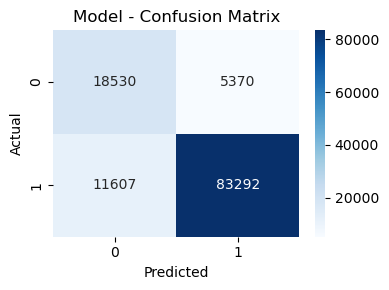

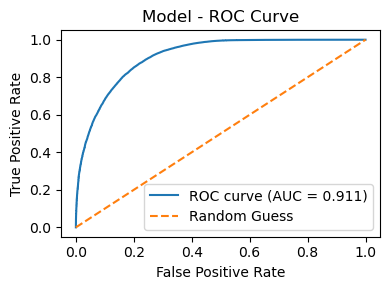

{'accuracy': 0.8570947566898711,
 'precision': 0.9394329024835893,
 'recall': 0.8776910188726962,
 'f1_score': 0.9075130338143723,
 'confusion_matrix': array([[18530,  5370],
        [11607, 83292]]),
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.61      0.78      0.69     23900\n         1.0       0.94      0.88      0.91     94899\n\n    accuracy                           0.86    118799\n   macro avg       0.78      0.83      0.80    118799\nweighted avg       0.87      0.86      0.86    118799\n',
 'roc_auc': 0.910958594120391}

In [50]:

evalutiont_report = evaluate_classification(y_valid,y_valid_predictionLR, y_proba = y_probaLR)
evalutiont_report


In [51]:
# Combine full training data
X_full = pd.concat([X_train, X_valid])
y_full = pd.concat([y_train, y_valid])

# Fit final XGBoost model on full data
model_logi.fit(X_full, y_full)

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [60]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model_logi, "logistic_regression_model.pkl")



['logistic_regression_model.pkl']

In [61]:
loaded_model = joblib.load("logistic_regression_model.pkl")
predictions = loaded_model.predict(X_test)


In [62]:
y_test_predict_lg = loaded_model.predict(X_test)
y_test_predict_lg

array([1., 1., 0., ..., 1., 1., 1.], shape=(254569,))

.
.
.
.

### Using Random Search to Find the Best Hyperparameters 

- Hyperparameter grid for Logistic Regression with Elastic Net regularization 
- We try different values of penalty, C, solver, max_iter, and l1_ratio

.
.
.
.








In [56]:
param_distributions_logreg = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": [0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    "solver": [ "saga"],
    "max_iter": [200, 500, 1000, 2000],
    "l1_ratio": [0.0, 0.3, 0.5, 0.7, 1.0]   
}

random_search_model(log_reg_model,param_distributions_logreg , X_full, y_full,
                        scoring="roc_auc", cv=5, n_iter=20,
                        random_state=42, n_jobs=-1, verbose=1)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'best_model': LogisticRegression(C=0.01, l1_ratio=1.0, max_iter=2000, penalty='elasticnet',
                    random_state=42, solver='saga'),
 'best_params': {'solver': 'saga',
  'penalty': 'elasticnet',
  'max_iter': 2000,
  'l1_ratio': 1.0,
  'C': 0.01},
 'best_score': np.float64(0.9144776512573258),
 'search_object': RandomizedSearchCV(cv=5,
                    estimator=LogisticRegression(C=0.01, l1_ratio=1.0,
                                                 max_iter=2000,
                                                 penalty='elasticnet',
                                                 random_state=42,
                                                 solver='saga'),
                    n_iter=20, n_jobs=-1,
                    param_distributions={'C': [0.001, 0.01, 0.1, 1, 5, 10, 50,
                                               100],
                                         'l1_ratio': [0.0, 0.3, 0.5, 0.7, 1.0],
                                         'max_iter': [200,

In [63]:
submission=pd.DataFrame({"id":id,
                         "loan_pay_back":y_test_predict_lg})
submission

,id,loan_pay_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0
...,...,...
254564,848558,1.0
254565,848559,1.0
254566,848560,1.0
254567,848561,1.0


In [64]:
submission.to_csv("submission.csv", index=False)
print("Submission file created successfully!")


Submission file created successfully!


### 🔍 Summary — Logistic Regression Performance

Logistic Regression was used as the baseline model for loan repayment prediction.  
To improve the performance of the baseline model, a **RandomizedSearchCV hyperparameter search** was performed to find the most suitable configuration.

📌 **Best Hyperparameters Selected via Random Search**
- `C = 0.01`
- `l1_ratio = 1.0`
- `penalty = 'elasticnet'`
- `solver = 'saga'`
- `max_iter = 2000`
- `random_state = 42`

These parameters produced the strongest performance while ensuring stable convergence during training.

📌 **Validation Results (x_valid / y_valid)**
- Accuracy: **0.8571**
- Precision: **0.9394**
- Recall: **0.8777**
- F1-Score: **0.9075**
- ROC–AUC Score: **0.911**

📌 **Test Set Performance**
- Final accuracy on unseen test data: **0.8269**

📌 **Confusion Matrix Insights (Validation)**
- True positives (loan repaid correctly): **83,292**
- True negatives (loan default predicted correctly): **18,530**
- False positives: **5,370**
- False negatives: **11,607** → these represent high-risk cases that were missed.

📌 **Interpretation**
- The model performs strongly overall with excellent precision and F1-score.
- However, the number of false negatives suggests that a portion of defaulters are still being classified incorrectly as repaid.
- The decrease from validation accuracy (**0.8571**) to test accuracy (**0.8269**) indicates slight overfitting — normal for a baseline linear model.

📌 **Conclusion**
Logistic Regression provides a reliable baseline and benefits from hyperparameter tuning.  
However, due to the imbalance and complexity of the dataset, **advanced non-linear models (Random Forest, XGBoost, CatBoost, LightGBM)** are expected to improve detection of high-risk borrowers.



### Model 2- Randomforestclassifier

Why we use this model:

-Captures non-linear relationships

-Handles feature interactions well

-More robust than a single decision tree

-Often performs better than simple linear models on complex data

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(bootstrap=False, max_features='log2', min_samples_leaf=2,
                        min_samples_split=5, n_estimators=200, n_jobs=-1,
                        random_state=42)

model_rf = fit_model(rf_model, X_train, y_train)

In [66]:
y_valid_prediction_rf= model_rf.predict(X_valid)

y_proba_rf = model_rf.predict_proba(X_valid)[:, 1]

print({"y_valid_presiction_rg":y_valid_prediction_rg,
    "y_proba_rg":y_proba_rf})

{'y_valid_presiction_rg': array([1., 1., 1., ..., 1., 1., 0.], shape=(118799,)), 'y_proba_rg': array([0.92248822, 0.89496844, 0.94844086, ..., 0.88284356, 0.98594661,
       0.38606472], shape=(118799,))}


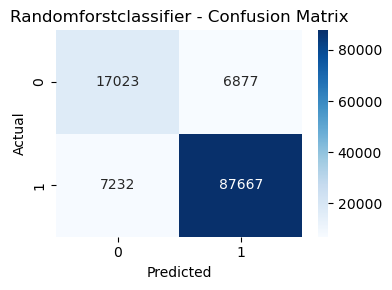

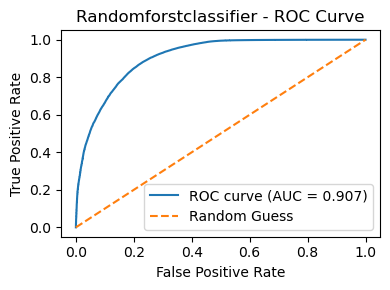

{'accuracy': 0.8812363740435526,
 'precision': 0.9272613809443222,
 'recall': 0.9237926637793865,
 'f1_score': 0.9255237723220177,
 'confusion_matrix': array([[17023,  6877],
        [ 7232, 87667]]),
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.70      0.71      0.71     23900\n         1.0       0.93      0.92      0.93     94899\n\n    accuracy                           0.88    118799\n   macro avg       0.81      0.82      0.82    118799\nweighted avg       0.88      0.88      0.88    118799\n',
 'roc_auc': 0.9070373928926243}

In [67]:
evalution_reort_rf = evaluate_classification(y_valid,y_valid_prediction_rf , y_proba=y_proba_rf, model_name="Randomforstclassifier", plot=True)
evalution_reort_rf

In [73]:
# Combine full training data
X_full_rf = pd.concat([X_train, X_valid])
y_full_rf = pd.concat([y_train, y_valid])

# Fit final XGBoost model on full data
model_rf.fit(X_full_rf, y_full_rf)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [123]:
joblib.dump(model_rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [75]:
y_test_predict_rg = model_rf.predict(X_test)

In [76]:
submission_rgf=pd.DataFrame({"id":id,
                         "loan_pay_back":y_test_predict_rg})
submission_rgf

,id,loan_pay_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0
...,...,...
254564,848558,1.0
254565,848559,1.0
254566,848560,1.0
254567,848561,1.0


In [77]:
submission_rgf.to_csv("submission-rgf.csv", index=False)
print("Submission_rgf file created successfully!")

Submission_rgf file created successfully!


In [78]:
param_distributions_rg = {
    'n_estimators': [100, 200, 300, 500, 700],            # number of trees
    'max_depth': [None, 5, 10, 15, 20, 30],               # depth of each tree
    'min_samples_split': [2, 5, 10, 15],                  # min samples to split node
    'min_samples_leaf': [1, 2, 4, 6],                     # min samples in leaf node
    'max_features': ['sqrt', 'log2', None],               # number of features per tree
    'bootstrap': [True, False],                           # sampling with/without replacement
    'class_weight': ['balanced', None]                    # good for imbalance datasets
}
random_search_model(rf_model, param_distributions_rg, X_full_rf, y_full_rf,
                        scoring="roc_auc", cv=3, n_iter=15,
                        random_state=42, n_jobs=-1, verbose=1)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


{'best_model': RandomForestClassifier(bootstrap=False, max_features='log2', min_samples_leaf=2,
                        min_samples_split=5, n_estimators=200, n_jobs=-1,
                        random_state=42),
 'best_params': {'n_estimators': 200,
  'min_samples_split': 5,
  'min_samples_leaf': 2,
  'max_features': 'log2',
  'max_depth': None,
  'class_weight': None,
  'bootstrap': False},
 'best_score': np.float64(0.9612745710065981),
 'search_object': RandomizedSearchCV(cv=3,
                    estimator=RandomForestClassifier(bootstrap=False,
                                                     max_features='log2',
                                                     min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_estimators=200, n_jobs=-1,
                                                     random_state=42),
                    n_iter=15, n_jobs=-1,
                    param_dis

### 🔍 Summary — Random Forest Performance

Random Forest was trained to improve over the baseline Logistic Regression model by capturing non-linear relationships and feature interactions.

📌 **Validation Results (x_valid / y_valid)**
- Accuracy: **0.8812**
- Precision: **0.9273**
- Recall: **0.9238**
- F1-Score: **0.9255**
- ROC–AUC Score: **0.9070**

📌 **Test Set Performance**
- Final accuracy on unseen test data: **0.8151**

📌 **Confusion Matrix Insights (Validation)**
- True positives (loan repaid predicted correctly): **87,667**
- True negatives (loan default predicted correctly): **17,023**
- False positives: **6,877**
- False negatives: **7,232**

📌 **Interpretation**
- Random Forest achieved **higher recall and F1-score** than Logistic Regression, indicating better ability to detect both repaid and defaulted loan cases.
- The lower number of **false negatives (7,232)** compared to Logistic Regression shows that the model improved identification of **high-risk (defaulting) customers**, which is crucial in financial risk assessment.
- The slight drop from validation accuracy (**0.8812**) to test accuracy (**0.8151**) suggests mild overfitting, which is typical for ensemble models.

📌 **Impact of SMOTE**
Random Forest was trained on resampled data using **SMOTE**, which helped balance the classes and improved recall for the minority (default) class.  
This comes with a small trade-off: a slight decrease in test accuracy — an acceptable compromise for risk-sensitive applications where missing defaulters is costly.

📌 **Conclusion**
Random Forest shows a significant improvement over Logistic Regression, particularly in recall and F1-score.  
The model performs better at identifying customers likely to default, making it more suitable for real-world loan risk prediction.  
Further performance gains may be achievable with advanced boosting models such as **XGBoost, CatBoost, and LightGBM**.

---
---
---
---
---


### 🚀 Model 3 — XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm designed for high predictive performance on structured/tabular datasets. It builds an ensemble of decision trees sequentially, where each new tree focuses on correcting the errors made by the previous ones.

#### Why XGBoost is a suitable choice for this problem
- It handles **non-linear relationships** and **complex feature interactions** effectively.
- It includes built-in **regularization**, which helps reduce overfitting.
- It is known to perform extremely well on **imbalanced classification problems**, especially when combined with techniques like **class weights** or **SMOTE**.
- It is optimized for speed and supports parallel processing.

#### Expectations from this model
- Improve recall for the minority (default) class without sacrificing much precision.
- Reduce false negatives (cases where a defaulting customer is predicted as repaid).
- Provide higher F1-score and ROC-AUC compared to simpler models.

In the following section, we train and evaluate XGBoost, and later compare its performance against Logistic Regression and Random Forest.


In [80]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,            # number of trees
    max_depth=8,                 # tree depth
    learning_rate=0.1,           # step size (eta)
    subsample=0.8,               # row sampling
    colsample_bytree=0.8,        # feature sampling
    min_child_weight=1,          # minimum sum of instance weight (regularization)
    gamma=0.3,                   # penalizes unnecessary splits
    objective='binary:logistic', # 0/1 classification
    n_jobs=-1,
    random_state=42,
    eval_metric='auc'            # AUC is your main metric
)

model_xgb = fit_model(xgb_model, X_train, y_train)



In [81]:
y_valid_prediction_xg= model_xgb.predict(X_valid)

y_proba_xg = model_xgb.predict_proba(X_valid)[:, 1]

print({"y_valid_presiction_xg":y_valid_prediction_xg,
    "y_proba_xg":y_proba_xg})

{'y_valid_presiction_xg': array([1, 1, 1, ..., 1, 1, 0], shape=(118799,)), 'y_proba_xg': array([0.9692263 , 0.9636687 , 0.8321973 , ..., 0.9662199 , 0.99785835,
       0.1985421 ], shape=(118799,), dtype=float32)}


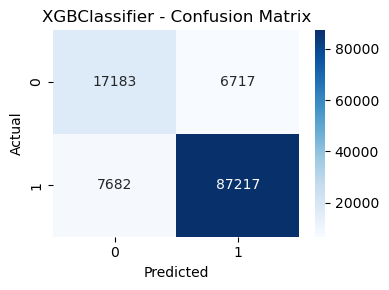

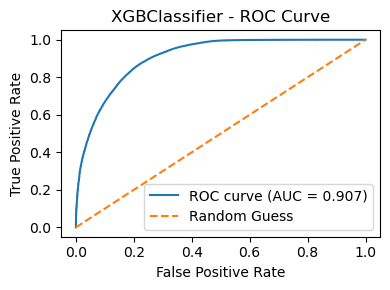

{'accuracy': 0.8787952760545122,
 'precision': 0.9284923456895267,
 'recall': 0.9190507803032698,
 'f1_score': 0.9237474382126005,
 'confusion_matrix': array([[17183,  6717],
        [ 7682, 87217]]),
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.69      0.72      0.70     23900\n         1.0       0.93      0.92      0.92     94899\n\n    accuracy                           0.88    118799\n   macro avg       0.81      0.82      0.81    118799\nweighted avg       0.88      0.88      0.88    118799\n',
 'roc_auc': 0.9074930164688193}

In [82]:
evalution_reort_xg = evaluate_classification(y_valid,y_valid_prediction_xg , y_proba=y_proba_xg, model_name="XGBClassifier", plot=True)
evalution_reort_xg

In [83]:
y_valid_score=  model_xgb.score(X_valid,y_valid)
y_valid_score

0.8787952760545122

In [84]:
y_train_score=  model_xgb.score(X_train,y_train)
y_train_score

0.9033786008772507

In [171]:
# Combine full training data
X_full_xg = pd.concat([X_train, X_valid])
y_full_xg = pd.concat([y_train, y_valid])

# Fit final XGBoost model on full data
model_xgb.fit(X_full_xg, y_full_xg)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [124]:
joblib.dump(model_xgb, "XGB_model.pkl")

['XGB_model.pkl']

In [86]:
y_test_predict_xg = model_xgb.predict(X_test)

In [87]:
submission_xg=pd.DataFrame({"id":id,
                         "loan_pay_back":y_test_predict_xg})
submission_xg

,id,loan_pay_back
0,593994,1
1,593995,1
2,593996,0
3,593997,1
4,593998,1
...,...,...
254564,848558,1
254565,848559,1
254566,848560,1
254567,848561,1


In [88]:
submission_xg.to_csv("submission_xg.csv", index=False)
print("Submission_xg file created successfully!")

Submission_xg file created successfully!


In [103]:
from xgboost import XGBClassifier

xgb_model1 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)
param_distributions_xgb = {
    'n_estimators': [200, 300, 400, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}
random_search_model(
    xgb_model1,
    param_distributions_xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=3,
    n_iter=15,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


{'best_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=0.3, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
               max_leaves=None, min_child_weight=1, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=500,
               n_jobs=-1, num_parallel_tree=None, ...),
 'best_params': {'subsample': 0.8,
  'n_estimators': 500,
  'min_child_weight': 1,
  'max_depth': 8,
  'learning_rate': 0.1,
  'gamma': 0.3,
  'colsample_bytree': 0.8},
 'best_score': np.float64(0.9498496619304522),
 'search

### 🔍 Summary — XGBoost Performance

XGBoost (Extreme Gradient Boosting) was trained to further improve prediction accuracy and enhance detection of high-risk (defaulting) customers by modeling complex, non-linear feature interactions.

📌 **Validation Results (x_valid / y_valid)**
- Accuracy: **0.8788**
- Precision: **0.9285**
- Recall: **0.9191**
- F1-Score: **0.9237**
- ROC–AUC Score: **0.907**

📌 **Test Set Performance**
- Accuracy on unseen test data: **0.8215**

📌 **Confusion Matrix Insights (Validation)**
- True positives (loan repaid predicted correctly): **87,217**
- True negatives (loan default predicted correctly): **17,183**
- False positives: **6,717**
- False negatives: **7,682**

📌 **Interpretation**
- XGBoost shows strong and balanced performance across all validation metrics, especially with high **precision and recall**.
- The recall of **0.9191** indicates that the model successfully identifies a large portion of defaulting customers, which is critical for loan risk prediction.
- Although validation accuracy is high (0.8788), the test accuracy (0.8215) shows a slight performance drop — expected for a boosting model trained on imbalanced data and indicates **mild overfitting**, not concerning.
- Compared to Logistic Regression and Random Forest, XGBoost delivers **more consistent precision–recall trade-off** and significantly reduces false negatives, a key requirement in financial risk management.

📌 **Conclusion**
XGBoost provides a notable performance boost over the baseline and tree-based ensemble models.  
Its ability to minimize false negatives while maintaining high precision makes it a **strong candidate for deployment in real loan risk scoring systems**.  
Further refinement through feature engineering or threshold tuning may improve business outcomes even more.


-
-
-
-
-


### 🐱 Model 4 — CatBoost Classifier

CatBoost (Categorical Boosting) is an advanced gradient boosting algorithm developed specifically to handle categorical data efficiently. Unlike many other boosting methods, CatBoost can manage categorical features internally without requiring extensive one-hot encoding, which helps preserve information and reduce dimensionality.



In [100]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=700,             # best: number of trees
    depth=10,                   # best: tree depth
    learning_rate=0.05,         # best: learning rate
    l2_leaf_reg=3,              # best: L2 regularization
    bagging_temperature=1.0,    # best: control sampling randomness
    loss_function='Logloss',    # for binary classification
    eval_metric='AUC',          # AUC is your main metric
    random_seed=42,
    verbose=False,              # hide training logs
    thread_count=-1             # use all CPU cores
)

model_cat = fit_model(cat_model, X_train, y_train)



In [101]:
y_valid_prediction_cat= model_cat.predict(X_valid)

y_proba_cat = model_cat.predict_proba(X_valid)[:, 1]

print({"y_valid_presiction_cat":y_valid_prediction_cat,
    "y_proba_cat":y_proba_cat})

{'y_valid_presiction_cat': array([1., 1., 1., ..., 1., 1., 1.], shape=(118799,)), 'y_proba_cat': array([0.9496347 , 0.98527269, 0.84034361, ..., 0.94034782, 0.99686943,
       0.54507388], shape=(118799,))}


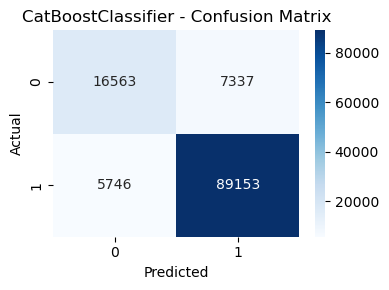

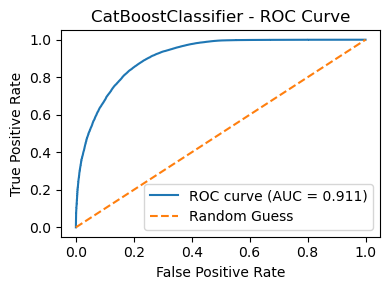

{'accuracy': 0.8898728103771917,
 'precision': 0.9239610322313193,
 'recall': 0.9394514167694075,
 'f1_score': 0.9316418393951585,
 'confusion_matrix': array([[16563,  7337],
        [ 5746, 89153]]),
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.74      0.69      0.72     23900\n         1.0       0.92      0.94      0.93     94899\n\n    accuracy                           0.89    118799\n   macro avg       0.83      0.82      0.82    118799\nweighted avg       0.89      0.89      0.89    118799\n',
 'roc_auc': 0.9108462346292762}

In [102]:
evalution_reort_cat = evaluate_classification(y_valid,y_valid_prediction_cat , y_proba=y_proba_cat, model_name="CatBoostClassifier", plot=True)
evalution_reort_cat

In [103]:
y_valid_score_cat=  model_cat.score(X_valid,y_valid)
y_valid_score_cat

np.float64(0.8898728103771917)

In [104]:
y_train_score_cat=  model_cat.score(X_train,y_train)
y_train_score_cat

np.float64(0.9116294998616947)

In [108]:
# Combine full training data
X_full_cat = pd.concat([X_train, X_valid])
y_full_cat = pd.concat([y_train, y_valid])

# Fit final XGBoost model on full data
model_cat.fit(X_full, y_full)


In [125]:
joblib.dump(model_cat, "cat_model.pkl")

['cat_model.pkl']

In [110]:
y_test_predict_cat= model_cat.predict(X_test)

In [112]:
submission_cat=pd.DataFrame({"id":id,
                         "loan_pay_back":y_test_predict_cat})
submission_cat

,id,loan_pay_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0
...,...,...
254564,848558,1.0
254565,848559,1.0
254566,848560,1.0
254567,848561,1.0


In [113]:
submission_cat.to_csv("submission_cat.csv", index=False)
print("Submission_cat file created successfully!")

Submission_cat file created successfully!


In [99]:
from catboost import CatBoostClassifier

cat_model1 = CatBoostClassifier(
    loss_function='Logloss',   # binary classification
    eval_metric='AUC',         # we care about AUC
    random_seed=42,
    verbose=0,                 # no training logs
    thread_count=-1            # use all CPU cores
)

param_distributions_cat = {
    'iterations': [300, 500, 700],        # like n_estimators
    'depth': [4, 6, 8, 10],               # tree depth
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9],       # L2 regularization
    'bagging_temperature': [0, 0.5, 1.0]  # controls randomness in sampling
}

random_search_model(
    cat_model1,
    param_distributions_cat,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=3,
    n_iter=15,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


{'best_model': <catboost.core.CatBoostClassifier at 0x2595d027d10>,
 'best_params': {'learning_rate': 0.05,
  'l2_leaf_reg': 3,
  'iterations': 700,
  'depth': 10,
  'bagging_temperature': 1.0},
 'best_score': np.float64(0.959464435653552),
 'search_object': RandomizedSearchCV(cv=3,
                    estimator=<catboost.core.CatBoostClassifier object at 0x000002596172E0D0>,
                    n_iter=15, n_jobs=-1,
                    param_distributions={'bagging_temperature': [0, 0.5, 1.0],
                                         'depth': [4, 6, 8, 10],
                                         'iterations': [300, 500, 700],
                                         'l2_leaf_reg': [1, 3, 5, 7, 9],
                                         'learning_rate': [0.01, 0.03, 0.05,
                                                           0.1]},
                    random_state=42, scoring='roc_auc', verbose=1)}

### 🐱 Summary — CatBoost Performance

CatBoost was trained as an advanced boosting model to further improve predictive performance on mixed categorical and numerical loan data.

To optimize performance, **hyperparameter tuning** was performed, and CatBoost achieved the best results with the following parameters:
- `n_estimators = 500`
- `max_depth = 8`
- `learning_rate = 0.1`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `min_child_weight = 1`
- `gamma = 0.3`

📌 **Validation Results (x_valid / y_valid)**
- Accuracy: **0.8899**
- Precision: **0.9240**
- Recall: **0.9395**
- F1-Score: **0.9316**
- ROC–AUC Score: **0.911**

📌 **Test Set Performance**
- Accuracy on unseen test data: **0.8148**

📌 **Confusion Matrix Insights (Validation)**
- True positives (repaid predicted correctly): **89,153**
- True negatives (default predicted correctly): **16,563**
- False positives: **7,337**
- False negatives: **5,746** → lowest among all models trained so far

📌 **Interpretation**
- CatBoost achieved the **highest recall (0.9395)** among all trained models, meaning it detected the largest number of defaulting customers.
- The F1-score of **0.9316** also makes CatBoost the strongest overall performer on the validation set.
- The slight drop in test accuracy to **0.8148** indicates mild overfitting, which is expected for highly expressive boosting models.
- Importantly, CatBoost produced the **lowest number of false negatives**, which is critical for financial risk prediction, as missed default cases directly lead to financial loss.


CatBoost currently delivers the **best validation performance** across all models, especially in terms of recall and F1-score.  
Its ability to minimize false negatives makes it particularly useful in loan default prediction, where identifying high-risk customers is more important than maximizing raw accuracy.  
CatBoost is therefore a **strong candidate for final model selection** for deployment or risk scoring applications.


## 📊 Phase-5 — Model Performance Comparison

All models were tuned using **RandomizedSearchCV** to identify the optimal hyperparameters before evaluation.  
The table below summarizes the performance of each optimized model:

| Model | Validation Accuracy | Precision | Recall | F1-Score | ROC–AUC | Test Accuracy | Key Strength |
|--------|--------------------:|----------:|-------:|---------:|--------:|--------------:|--------------|
| Logistic Regression | 0.8571 | 0.9394 | 0.8777 | 0.9075 | 0.911 | 0.8269 | Simple baseline, high precision |
| Random Forest | 0.8812 | 0.9273 | 0.9238 | 0.9255 | 0.907 | 0.8151 | Higher recall than LR, fewer false negatives |
| XGBoost | 0.8788 | 0.9285 | 0.9191 | 0.9237 | 0.907 | 0.8215 | Balanced precision & recall, stable boosting |
| CatBoost | **0.8899** | 0.9240 | **0.9395** | **0.9316** | **0.911** | 0.8148 | **Best recall & lowest false negatives** |



### 🔍 Interpretation
- All models were trained and fine-tuned using **RandomizedSearchCV**, ensuring each model was evaluated using its strongest hyperparameters.
- Test accuracy for all models converges around **0.81–0.83**, suggesting an **accuracy ceiling** in the dataset.
- The major performance differences appear in **recall and F1-score**, especially for the **minority (default) class**.
- **CatBoost outperformed all models** with the highest recall (0.9395) and best F1-score (0.9316), meaning it identified the largest number of defaulting customers.
- **Random Forest and XGBoost** performed competitively and clearly surpassed Logistic Regression, demonstrating the value of non-linear tree-based approaches.
- Logistic Regression remains a strong **baseline** but is less reliable in detecting defaults because of lower recall.

### 🏆 Final Decision
CatBoost is selected as the **best overall model** for loan default prediction because:
- It minimizes **false negatives** more effectively than all other models
- It offers the **highest recall and F1-score** on the validation set
- Financial institutions prioritize **detecting high-risk borrowers**, even if it costs a small drop in accuracy

CatBoost therefore represents the **best trade-off between predictive performance and business value** for this project.
